# Telco Customer Churn — Exploratory Data Analysis

Source table: `clean_customers` in `data/churn.duckdb`, built by `sql/01_ingest.sql`
and `sql/02_clean.sql`.

This notebook is **description only — no modeling**. Its job is to answer six
questions and to settle one feature-engineering decision (whether `TotalCharges`
earns a place in the model matrix).

| # | Question |
|---|---|
| 1 | Class balance — how skewed is the target? |
| 2 | Churn rate by payment method — is electronic check really that bad? |
| 3 | Churn vs tenure — where in the lifecycle do customers leave? |
| 4 | Churn by internet service — fiber vs DSL vs none |
| 5 | MonthlyCharges vs churn — do expensive customers leave more? |
| 6 | Add-on services — do "sticky" services retain? |
| 7 | Correlation among numeric features — redundancy check |

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Locate the repo root from wherever this notebook is run.
ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "data" / "churn.duckdb").exists()
)

con = duckdb.connect(str(ROOT / "data" / "churn.duckdb"), read_only=True)
df = con.execute("SELECT * FROM clean_customers").df()
con.close()

print(f"loaded {df.shape[0]:,} rows x {df.shape[1]} columns from clean_customers")
df.head()

loaded 7,043 rows x 22 columns from clean_customers


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,churn_flag
0,7590-VHVEG,Female,No,Yes,No,1,No,No,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,No,No,No,45,No,No,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [2]:
# --- Plot style -------------------------------------------------------------
# Two-series charts use categorical slots 1 and 2; single-measure charts use
# slot 1 only. Colour never encodes rank, so bars are not recoloured by size --
# an overall-rate reference line carries that comparison instead.
BLUE   = "#2a78d6"   # slot 1 -- retained, and all single-measure bars
ORANGE = "#eb6834"   # slot 2 -- churned
INK    = "#0b0b0b"
INK_2  = "#52514e"
GRID   = "#e5e4e0"

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK_2,
    "axes.titlecolor": INK,
    "axes.titlesize": 12,
    "axes.titleweight": "semibold",
    "axes.titlelocation": "left",
    "axes.titlepad": 10,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "xtick.color": INK_2,
    "ytick.color": INK_2,
    "text.color": INK,
    "legend.frameon": False,
    "font.size": 10,
    "lines.linewidth": 2,
})

OVERALL = df.churn_flag.mean()

def despine(ax, keep=("left", "bottom")):
    for side, spine in ax.spines.items():
        spine.set_visible(side in keep)

def rate_by(column, order=None):
    # Churn rate (%) and group size for one categorical column.
    out = (df.groupby(column, observed=True)
             .agg(n=("churn_flag", "size"), churn_rate=("churn_flag", "mean")))
    out["churn_rate"] *= 100
    return out.loc[order] if order is not None else out.sort_values("churn_rate")

# A white halo behind value labels so the dashed reference line never cuts
# through the digits. Static charts have no hover layer to fall back on, so
# every bar is direct-labelled and the labels have to stay legible.
HALO = dict(facecolor="white", edgecolor="none", pad=1.2, alpha=0.85)

def label_barh(ax, values, labels, pad=0.6):
    # Labels sit outside the bar end, flipping side for negative bars.
    for y, (v, text) in enumerate(zip(values, labels)):
        ha = "left" if v >= 0 else "right"
        ax.text(v + (pad if v >= 0 else -pad), y, text, va="center", ha=ha,
                fontsize=9, color=INK_2, bbox=HALO)

def overall_line(ax, vertical=True, annotate=False):
    draw = ax.axvline if vertical else ax.axhline
    draw(OVERALL * 100, color=INK_2, linestyle="--", linewidth=1.2, zorder=1)
    if annotate:
        # Anchor to the top of the plot area, clear of the tick labels.
        ax.text(OVERALL * 100 + 0.8, ax.get_ylim()[1] - 0.12,
                f"overall {OVERALL:.1%}", fontsize=9, color=INK_2,
                va="top", ha="left", bbox=HALO)

print(f"overall churn rate: {OVERALL:.2%}")

overall churn rate: 26.54%


## 1. Class balance

,customers,share
Churn,,
No,5174,73.46%
Yes,1869,26.54%


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


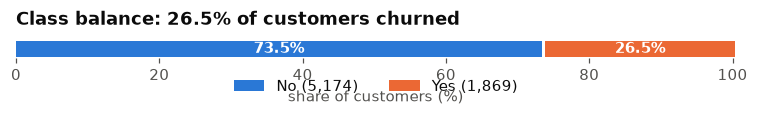

In [3]:
counts = df.Churn.value_counts().reindex(["No", "Yes"])
share = counts / counts.sum()

summary = pd.DataFrame({
    "customers": counts,
    "share": (100 * share).round(2).astype(str) + "%",
})
summary.index.name = "Churn"
display(summary)

fig, ax = plt.subplots(figsize=(7, 1.6))
left = 0
for label, colour in [("No", BLUE), ("Yes", ORANGE)]:
    width = share[label] * 100
    ax.barh(0, width, left=left, height=0.5, color=colour,
            label=f"{label} ({counts[label]:,})")
    ax.text(left + width / 2, 0, f"{width:.1f}%", ha="center", va="center",
            color="white", fontsize=10, fontweight="semibold")
    left += width + 0.4          # 2px-equivalent surface gap between segments

ax.set_xlim(0, 100.4)
ax.set_yticks([])
ax.set_xlabel("share of customers (%)")
ax.set_title("Class balance: 26.5% of customers churned")
ax.grid(False)
despine(ax, keep=())
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.45), ncol=2)
plt.tight_layout()
plt.show()

**Takeaway.** 1,869 of 7,043 customers churned — a **26.5% positive rate**. That is
imbalanced but not severely so; it is well within the range where a plain classifier
trains sensibly, and it does not call for resampling. Two consequences for later phases:
accuracy is a useless headline metric here (predicting "nobody churns" scores 73.5%),
so evaluation should lead with precision/recall or ROC-AUC; and every churn rate below
should be read against this **26.5% baseline**, marked as a dashed line on the charts
that follow.

## 2. Churn rate by payment method

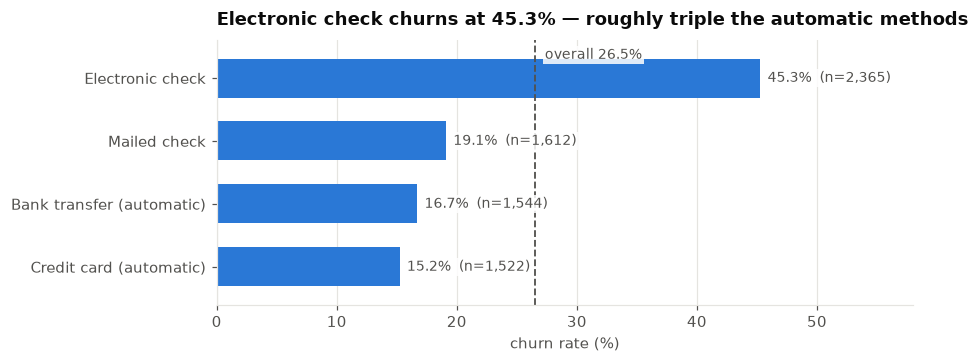

,n,churn_rate
PaymentMethod,,
Credit card (automatic),1522,15.2
Bank transfer (automatic),1544,16.7
Mailed check,1612,19.1
Electronic check,2365,45.3


In [4]:
pay = rate_by("PaymentMethod")

fig, ax = plt.subplots(figsize=(8.5, 3.4))
ax.barh(pay.index, pay.churn_rate, color=BLUE, height=0.62)
label_barh(ax, pay.churn_rate,
           [f"{v:.1f}%  (n={n:,})" for v, n in zip(pay.churn_rate, pay.n)])
ax.set_xlim(0, 58)
ax.set_ylim(-0.6, len(pay) - 0.4)
overall_line(ax, annotate=True)
ax.set_xlabel("churn rate (%)")
ax.set_title("Electronic check churns at 45.3% — roughly triple the automatic methods")
ax.grid(axis="y", visible=False)
despine(ax)
plt.tight_layout()
plt.show()

display(pay.assign(churn_rate=pay.churn_rate.round(1)))

**Takeaway. Confirmed — and it is the single strongest categorical signal in the file.**
Electronic check churns at **45.3%**, against 19.1% for mailed check and roughly 15–17%
for the two automatic methods. That is a ~30-point spread, and electronic check is not a
niche segment: at **2,365 customers it is the largest** of the four.

The obvious causal story — "manual payment means monthly re-consent, so the customer
re-decides every month" — is plausible but **unproven from this table**, and section 4
shows electronic check is heavily entangled with fiber. Treat it as a strong *predictor*
and a sensible *targeting flag* (a migration offer to autopay is cheap to test), not as
an established cause.

## 3. Churn vs tenure

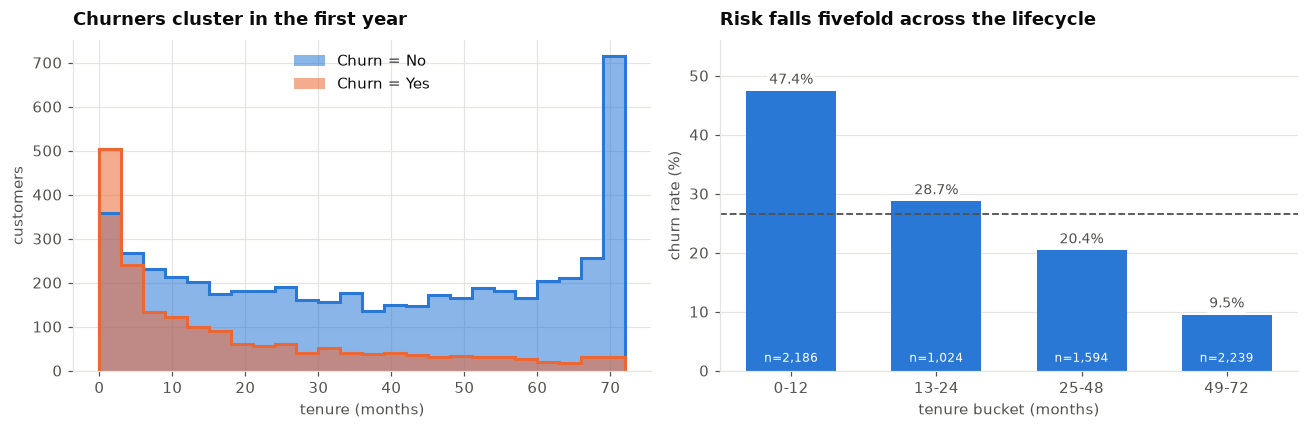

,n,churn_rate
tenure_bucket,,
0-12,2186,47.4
13-24,1024,28.7
25-48,1594,20.4
49-72,2239,9.5


       mean   50%   25%   75%
Churn                        
No     37.6  38.0  15.0  61.0
Yes    18.0  10.0   2.0  29.0


In [5]:
BUCKETS = [-1, 12, 24, 48, 72]
NAMES = ["0-12", "13-24", "25-48", "49-72"]
df["tenure_bucket"] = pd.cut(df.tenure, BUCKETS, labels=NAMES)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: distribution overlap.
bins = np.arange(0, 74, 3)
for label, colour in [("No", BLUE), ("Yes", ORANGE)]:
    subset = df.loc[df.Churn == label, "tenure"]
    ax1.hist(subset, bins=bins, color=colour, alpha=0.55, label=f"Churn = {label}")
    ax1.hist(subset, bins=bins, histtype="step", color=colour, linewidth=2)

ax1.set_xlabel("tenure (months)")
ax1.set_ylabel("customers")
ax1.set_title("Churners cluster in the first year")
ax1.legend(loc="upper center")
despine(ax1)

# Right: churn rate by bucket.
buckets = rate_by("tenure_bucket", order=NAMES)
ax2.bar(buckets.index, buckets.churn_rate, color=BLUE, width=0.62)
for x, (v, n) in enumerate(zip(buckets.churn_rate, buckets.n)):
    ax2.text(x, v + 1.2, f"{v:.1f}%", ha="center", fontsize=9, color=INK_2, bbox=HALO)
    ax2.text(x, 1.5, f"n={n:,}", ha="center", fontsize=8, color="white")

overall_line(ax2, vertical=False)
ax2.set_ylim(0, 56)
ax2.set_ylabel("churn rate (%)")
ax2.set_xlabel("tenure bucket (months)")
ax2.set_title("Risk falls fivefold across the lifecycle")
ax2.grid(axis="x", visible=False)
despine(ax2)

plt.tight_layout()
plt.show()

display(buckets.assign(churn_rate=buckets.churn_rate.round(1)))
print(df.groupby("Churn")["tenure"].describe()[["mean", "50%", "25%", "75%"]].round(1))

**Takeaway.** Tenure is the strongest numeric predictor, and the two distributions
overlap only in the middle. Churners have a **median tenure of 10 months** against
**38 months** for those who stay, and the effect is monotone across buckets:

| bucket | n | churn rate |
|---|---|---|
| 0–12 | 2,186 | **47.4%** |
| 13–24 | 1,024 | 28.7% |
| 25–48 | 1,594 | 20.4% |
| 49–72 | 2,239 | **9.5%** |

Nearly **half of first-year customers leave**, and risk decays fivefold by the final
bucket. Note the bimodal shape in the left panel: this base is barbelled into a large
new-customer cohort and a large long-tenured one, so aggregate churn is a blend of two
very different populations. The `0-12` bucket is where retention spend has the most room
to work — it holds 31% of the base and 55% of all churn. This monotonicity is what
justifies `add_tenure_bucket` in `src/features.py`: the bins are coarse enough to stay
legible while preserving the ordering.

## 4. Churn by internet service type

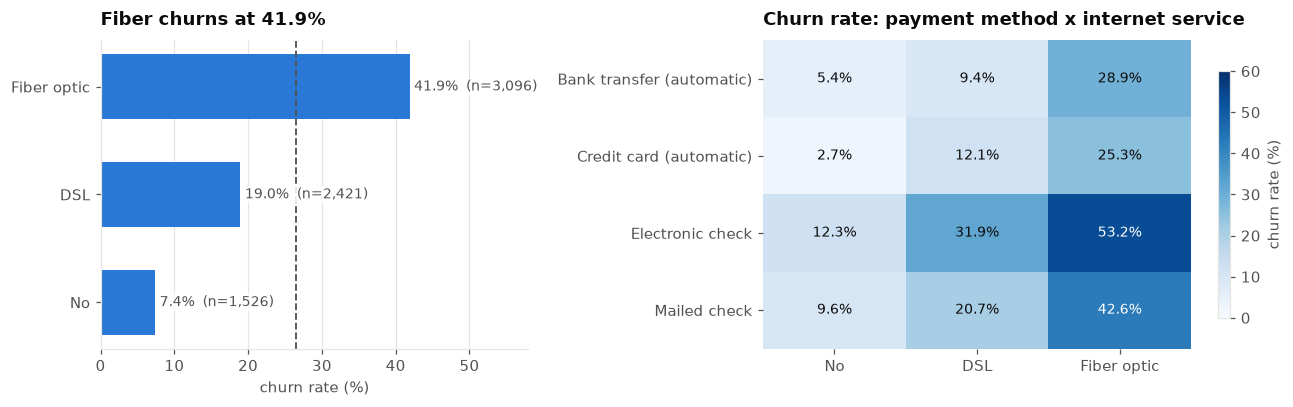

,n,churn_rate
InternetService,,
No,1526,7.4
DSL,2421,19.0
Fiber optic,3096,41.9


In [6]:
net = rate_by("InternetService", order=["No", "DSL", "Fiber optic"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.8),
                               gridspec_kw={"width_ratios": [1, 1.25]})

ax1.barh(net.index, net.churn_rate, color=BLUE, height=0.6)
label_barh(ax1, net.churn_rate,
           [f"{v:.1f}%  (n={n:,})" for v, n in zip(net.churn_rate, net.n)])
overall_line(ax1)
ax1.set_xlim(0, 58)
ax1.set_xlabel("churn rate (%)")
ax1.set_title("Fiber churns at 41.9%")
ax1.grid(axis="y", visible=False)
despine(ax1)

# Payment method x internet service: is electronic check just a fiber proxy?
cross = (df.pivot_table(index="PaymentMethod", columns="InternetService",
                        values="churn_flag", aggfunc="mean")
           .reindex(columns=["No", "DSL", "Fiber optic"]) * 100)

im = ax2.imshow(cross.values, cmap="Blues", vmin=0, vmax=60, aspect="auto")
ax2.set_xticks(range(len(cross.columns)), cross.columns)
ax2.set_yticks(range(len(cross.index)), cross.index)
for i in range(cross.shape[0]):
    for j in range(cross.shape[1]):
        v = cross.values[i, j]
        ax2.text(j, i, f"{v:.1f}%", ha="center", va="center", fontsize=9,
                 color="white" if v > 32 else INK)
ax2.set_title("Churn rate: payment method x internet service")
ax2.grid(False)
despine(ax2, keep=())
fig.colorbar(im, ax=ax2, shrink=0.8, label="churn rate (%)")

plt.tight_layout()
plt.show()

display(net.assign(churn_rate=net.churn_rate.round(1)))

**Takeaway.** Internet service separates the base cleanly: **fiber 41.9%**, DSL 19.0%,
no internet **7.4%** — a 34-point spread, second only to contract type. Customers with no
internet service are extraordinarily loyal, which fits an older, phone-only, long-tenured
segment.

The heatmap is the more useful panel, because it shows the two headline findings are
**entangled rather than independent**. Fiber *and* electronic check together churn at
**53.2%** (n=1,595) — the worst cell in the table — while fiber on a credit card sits at
25.3% and DSL on bank transfer at 9.4%. Electronic check raises churn *within every*
internet tier, so it is not merely a proxy for fiber; but a large share of its raw 45.3%
comes from the fact that fiber customers disproportionately pay that way. A model with
both variables will apportion this; a univariate reading of either one overstates it.

Fiber being the premium, most expensive product yet the worst-retaining one is the
central tension in this dataset, and section 5 picks it up.

## 5. MonthlyCharges vs churn

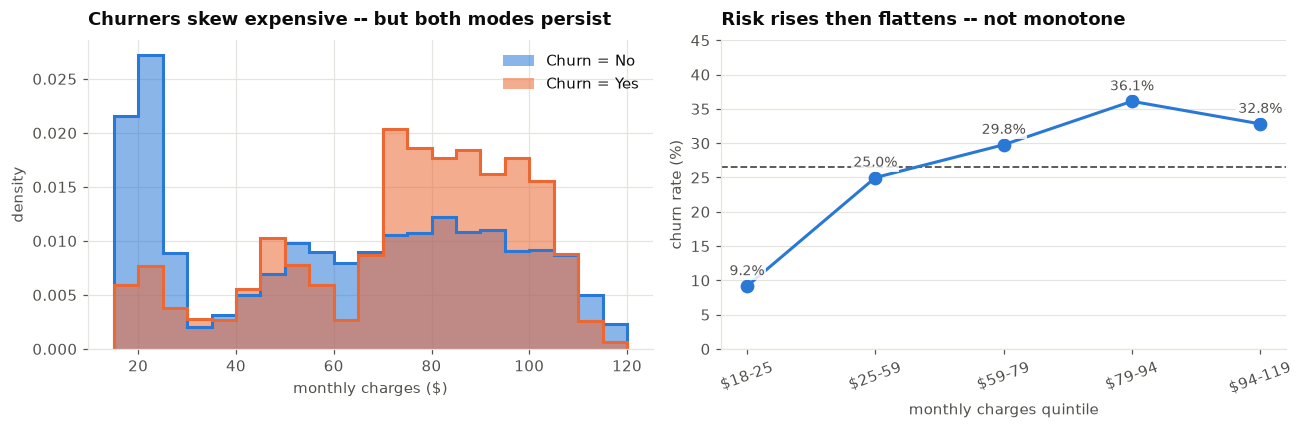

,n,churn_rate
q,,
"(18.249, 25.05]",1420,9.2
"(25.05, 58.83]",1397,25.0
"(58.83, 79.1]",1411,29.8
"(79.1, 94.25]",1407,36.1
"(94.25, 118.75]",1408,32.8


        mean  median
Churn               
No     61.27   64.43
Yes    74.44   79.65


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

bins = np.arange(15, 125, 5)
for label, colour in [("No", BLUE), ("Yes", ORANGE)]:
    subset = df.loc[df.Churn == label, "MonthlyCharges"]
    ax1.hist(subset, bins=bins, color=colour, alpha=0.55, label=f"Churn = {label}",
             density=True)
    ax1.hist(subset, bins=bins, histtype="step", color=colour, linewidth=2,
             density=True)

ax1.set_xlabel("monthly charges ($)")
ax1.set_ylabel("density")
ax1.set_title("Churners skew expensive -- but both modes persist")
ax1.legend(loc="upper right")
despine(ax1)

quint = (df.assign(q=pd.qcut(df.MonthlyCharges, 5))
           .groupby("q", observed=True)
           .agg(n=("churn_flag", "size"), churn_rate=("churn_flag", "mean")))
quint["churn_rate"] *= 100
labels = [f"${i.left:.0f}-{i.right:.0f}" for i in quint.index]

ax2.plot(labels, quint.churn_rate, color=BLUE, marker="o", markersize=8)
for x, v in enumerate(quint.churn_rate):
    ax2.text(x, v + 1.6, f"{v:.1f}%", ha="center", fontsize=9, color=INK_2, bbox=HALO)
overall_line(ax2, vertical=False)

ax2.set_ylim(0, 45)
ax2.set_ylabel("churn rate (%)")
ax2.set_xlabel("monthly charges quintile")
ax2.set_title("Risk rises then flattens -- not monotone")
ax2.tick_params(axis="x", labelrotation=20)
ax2.grid(axis="x", visible=False)
despine(ax2)

plt.tight_layout()
plt.show()

display(quint.assign(churn_rate=quint.churn_rate.round(1)))
print(df.groupby("Churn")["MonthlyCharges"].agg(["mean", "median"]).round(2))

**Takeaway. Yes, but the relationship bends — and that matters for model choice.**
Churners pay a **median $79.65/mo** against **$64.43** for those who stay. By quintile:

| quintile | churn rate |
|---|---|
| $18–25 | **9.2%** |
| $25–59 | 25.0% |
| $59–79 | 29.8% |
| $79–94 | **36.1%** |
| $94–119 | 32.8% |

Risk climbs steeply out of the cheap tier, then **flattens and slightly reverses** at the
top — the most expensive quintile churns *less* than the one below it. The cheapest
quintile is essentially the phone-only, no-internet segment from section 4, and it is the
loyalty anchor of the whole base.

Two implications. First, the non-monotonicity means a **linear term on `MonthlyCharges`
will underfit**; tree-based models (XGBoost, per the requirements) handle the bend
natively, and a logistic baseline would want the binned or spline version. Second,
price alone is not the story — the top quintile is heavy in long-tenured bundle
customers whose tenure protects them, which is exactly the interaction a model is for.

## 6. Add-on services vs churn

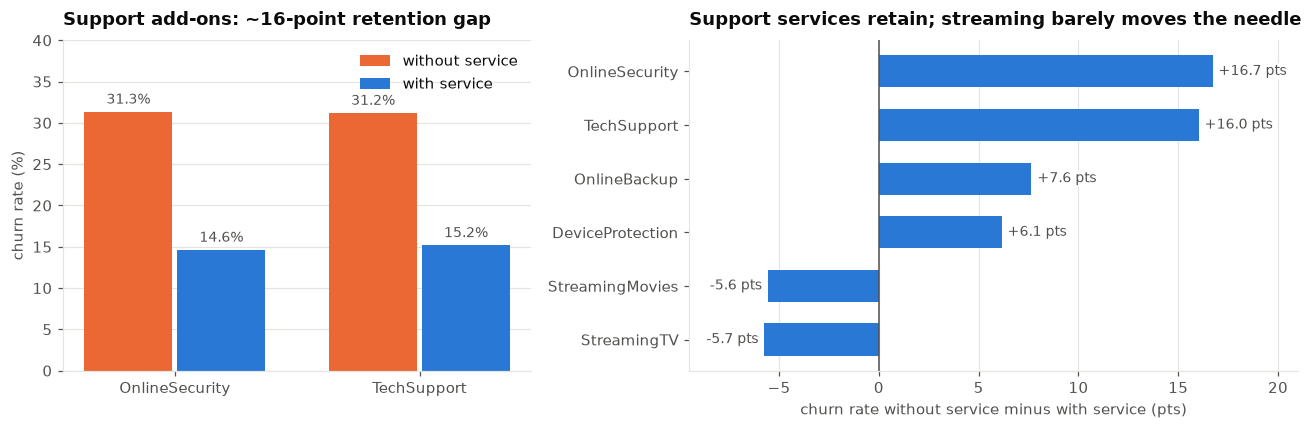

,no_n,no_rate,yes_n,yes_rate,gap_pts
service,,,,,
OnlineSecurity,5024,31.3,2019,14.6,16.7
TechSupport,4999,31.2,2044,15.2,16.0
OnlineBackup,4614,29.2,2429,21.5,7.6
DeviceProtection,4621,28.7,2422,22.5,6.1
StreamingTV,4336,24.3,2707,30.1,-5.7
StreamingMovies,4311,24.4,2732,29.9,-5.6


In [8]:
ADDONS = ["OnlineSecurity", "TechSupport", "OnlineBackup", "DeviceProtection",
          "StreamingTV", "StreamingMovies"]

rows = []
for col in ADDONS:
    g = df.groupby(col, observed=True).churn_flag.agg(["size", "mean"])
    rows.append({
        "service": col,
        "no_n": g.loc["No", "size"], "no_rate": 100 * g.loc["No", "mean"],
        "yes_n": g.loc["Yes", "size"], "yes_rate": 100 * g.loc["Yes", "mean"],
    })
addons = pd.DataFrame(rows).set_index("service")
addons["gap_pts"] = addons.no_rate - addons.yes_rate

focus = addons.loc[["OnlineSecurity", "TechSupport"]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4),
                               gridspec_kw={"width_ratios": [1, 1.3]})

# Left: the two "sticky" services the brief asks about.
x = np.arange(len(focus))
w = 0.36
ax1.bar(x - w / 2 - 0.01, focus.no_rate, w, color=ORANGE, label="without service")
ax1.bar(x + w / 2 + 0.01, focus.yes_rate, w, color=BLUE, label="with service")
for i, (no_v, yes_v) in enumerate(zip(focus.no_rate, focus.yes_rate)):
    ax1.text(i - w / 2 - 0.01, no_v + 1.0, f"{no_v:.1f}%", ha="center", fontsize=9, color=INK_2)
    ax1.text(i + w / 2 + 0.01, yes_v + 1.0, f"{yes_v:.1f}%", ha="center", fontsize=9, color=INK_2)

ax1.set_xticks(x, focus.index)
ax1.set_ylim(0, 40)
ax1.set_ylabel("churn rate (%)")
ax1.set_title("Support add-ons: ~16-point retention gap")
ax1.legend(loc="upper right")
ax1.grid(axis="x", visible=False)
despine(ax1)

# Right: all six, ranked by gap -- support vs entertainment.
ranked = addons.sort_values("gap_pts")
ax2.barh(ranked.index, ranked.gap_pts, color=BLUE, height=0.6)
label_barh(ax2, ranked.gap_pts, [f"{v:+.1f} pts" for v in ranked.gap_pts], pad=0.3)
ax2.axvline(0, color=INK_2, linewidth=1)
ax2.set_xlim(-9.5, 21)
ax2.set_xlabel("churn rate without service minus with service (pts)")
ax2.set_title("Support services retain; streaming barely moves the needle")
ax2.grid(axis="y", visible=False)
despine(ax2)

plt.tight_layout()
plt.show()

display(addons.round(1))

**Takeaway. The support add-ons retain; the entertainment add-ons essentially do not.**

| service | without | with | gap |
|---|---|---|---|
| OnlineSecurity | 31.3% | **14.6%** | 16.7 pts |
| TechSupport | 31.2% | **15.2%** | 16.0 pts |
| OnlineBackup | 29.2% | 21.5% | 7.6 pts |
| DeviceProtection | 28.7% | 22.5% | 6.1 pts |
| StreamingTV | 24.3% | 30.1% | −5.7 pts |
| StreamingMovies | 24.4% | 29.9% | −5.6 pts |

OnlineSecurity and TechSupport each cut churn by more than half. The two streaming
services run the *opposite* way — customers who have them churn slightly **more** — which
is the fiber effect resurfacing, since streaming is bundled with the high-priced fiber
tier that section 4 flagged.

The causal caution matters here more than anywhere else in the notebook, because this
finding is the most actionable-looking and the most confounded. Customers who add
security and support are plausibly the more engaged, more committed ones to begin with;
the add-on may be a *marker* of that commitment rather than its cause. The observed gap
is an **upper bound** on what bundling these services free would achieve, and the honest
test is an experiment, not this table. What the pattern does justify cleanly is the
`add_service_count` feature — the *count* of add-ons carries the engagement signal in a
single numeric column, and its support-vs-entertainment split is why the raw indicators
are worth keeping alongside it.

## 7. Correlation among numeric features

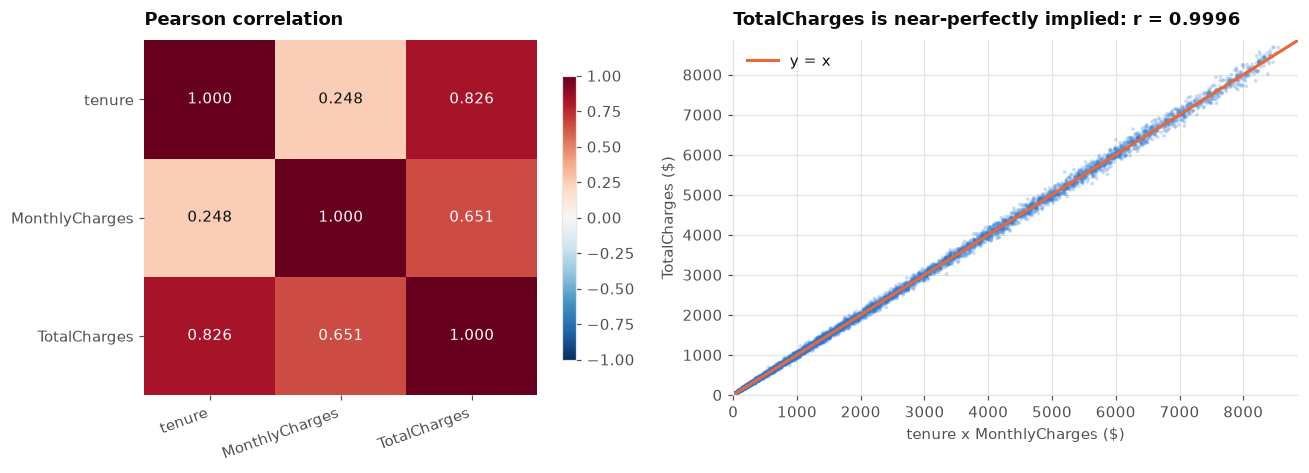

                tenure  MonthlyCharges  TotalCharges
tenure           1.000           0.248         0.826
MonthlyCharges   0.248           1.000         0.651
TotalCharges     0.826           0.651         1.000

corr(TotalCharges, tenure x MonthlyCharges) = 0.9996
corr(TotalCharges, tenure)                  = 0.8262
corr(TotalCharges, churn_flag)              = -0.1983

residual (TotalCharges - tenure x MonthlyCharges), $:
count    7043.0
mean        0.2
std        67.2
min      -370.8
25%       -28.6
50%         0.0
75%        28.5
max       373.3


In [9]:
NUMERIC = ["tenure", "MonthlyCharges", "TotalCharges"]
corr = df[NUMERIC].corr()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4),
                               gridspec_kw={"width_ratios": [1, 1.15]})

# Diverging scale: correlation is polar data, so blue<->red around a neutral 0.
im = ax1.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax1.set_xticks(range(3), NUMERIC, rotation=20, ha="right")
ax1.set_yticks(range(3), NUMERIC)
for i in range(3):
    for j in range(3):
        v = corr.values[i, j]
        ax1.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=10,
                 color="white" if abs(v) > 0.6 else INK)
ax1.set_title("Pearson correlation")
ax1.grid(False)
despine(ax1, keep=())
fig.colorbar(im, ax=ax1, shrink=0.8)

# The redundancy test: is TotalCharges just tenure x MonthlyCharges?
implied = df.tenure * df.MonthlyCharges
r = df.TotalCharges.corr(implied)

ax2.scatter(implied, df.TotalCharges, s=6, alpha=0.25, color=BLUE,
            edgecolors="none")
lim = [0, max(implied.max(), df.TotalCharges.max()) * 1.02]
ax2.plot(lim, lim, color=ORANGE, linewidth=2, label="y = x")
ax2.set_xlim(lim)
ax2.set_ylim(lim)
ax2.set_xlabel("tenure x MonthlyCharges ($)")
ax2.set_ylabel("TotalCharges ($)")
ax2.set_title(f"TotalCharges is near-perfectly implied: r = {r:.4f}")
ax2.legend(loc="upper left")
despine(ax2)

plt.tight_layout()
plt.show()

print(corr.round(3))
print()
print(f"corr(TotalCharges, tenure x MonthlyCharges) = {r:.4f}")
print(f"corr(TotalCharges, tenure)                  = {df.TotalCharges.corr(df.tenure):.4f}")
print(f"corr(TotalCharges, churn_flag)              = {df.TotalCharges.corr(df.churn_flag):.4f}")

resid = df.TotalCharges - implied
print()
print("residual (TotalCharges - tenure x MonthlyCharges), $:")
print(resid.describe().round(1).to_string())

**Takeaway. `TotalCharges` is redundant and should be dropped from the model matrix.**

`corr(TotalCharges, tenure × MonthlyCharges) = 0.9996` — the scatter is a straight line on
`y = x` with only mild fanning at high values, which is the residue of customers whose
plan changed mid-life (the product uses their *final* monthly rate against their *whole*
billing history). `TotalCharges` also correlates 0.826 with `tenure` on its own.

So the column carries **almost no information that `tenure` and `MonthlyCharges` do not
already carry**, while adding a third collinear input. Keeping it inflates coefficient
variance and makes any linear model's coefficients unstable and unreadable — the classic
multicollinearity failure — and it splits importance across correlated columns in a tree
model, hiding tenure's true contribution.

**Decision: `encode_features` drops `TotalCharges`.** The genuinely new information in it
is the *discrepancy* from the implied product, which `add_charges_per_tenure` captures
directly as `charges_per_tenure` and `charges_ratio` — a bounded ratio rather than a
third copy of the same quantity.

Note that this makes the raw correlation with churn (−0.198) misleading: it is tenure's
signal wearing a different name.

## Summary

| # | Question | Finding |
|---|---|---|
| 1 | Class balance | 26.5% churn (1,869 / 7,043) — imbalanced but workable; don't report accuracy |
| 2 | Payment method | **Electronic check 45.3%** vs ~15–17% autopay — confirmed, largest segment too |
| 3 | Tenure | Median 10 mo (churn) vs 38 mo (stay); **47.4% churn in year one**, 9.5% after four years |
| 4 | Internet service | **Fiber 41.9%**, DSL 19.0%, none 7.4%; fiber + e-check = **53.2%**, the worst cell |
| 5 | MonthlyCharges | Yes, but **non-monotone** — peaks at the $79–94 quintile, dips at the top |
| 6 | Add-ons | Security/support cut churn ~16 pts; **streaming does not retain** (−5 pts, wrong way) |
| 7 | Correlation | `TotalCharges ≈ tenure × MonthlyCharges` at **r = 0.9996** → drop it |

**The composite high-risk profile** — month-to-month fiber customer, under a year in,
paying by electronic check, no security or support add-ons — stacks every factor above.
Contract type, surfaced incidentally, is the strongest single split in the file
(month-to-month 42.7% vs two-year 2.8%) and should be in the model.

**A standing caveat on all of it:** these are univariate cross-tabs on observational
data. Section 4 demonstrated the hazard concretely — electronic check and fiber each
looked like independent effects until crossed, and each absorbs some of the other's
apparent strength. Read these as ranked *predictors*, not as an intervention list.

**Carried into `src/features.py`:** `tenure_bucket` (§3), `service_count` (§6),
`charges_per_tenure` (§7), and the decision to drop `TotalCharges` (§7).